#### Importing Libraries

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

#### Loading Datasets

In [6]:
os.chdir("C:/Users/Souradeep/OneDrive/Desktop/Publications/Artha 2026_Paper/Currency Data")
BTC_USD = pd.read_csv("Bitcoin Historical Data.csv")
ETH_USD = pd.read_csv("ETH_USD Binance Historical Data.csv")
EUR_USD = pd.read_csv("EUR_USD Historical Data.csv")
GBP_USD = pd.read_csv("GBP_USD Historical Data.csv")
AUD_USD = pd.read_csv("AUD_USD Historical Data.csv")
USD_CHF = pd.read_csv("USD_CHF Historical Data.csv")
USD_JPY = pd.read_csv("USD_JPY Historical Data.csv")
USD_INR = pd.read_csv("USD_INR Historical Data.csv")

#### Cleaning Data

In [7]:
BTC_USD['Date'] = pd.to_datetime(BTC_USD['Date'].str.replace("/", "-", regex=False), format="%d-%m-%Y")
BTC_USD = BTC_USD.sort_values(by = 'Date', ascending = True)
BTC_USD.set_index('Date', inplace = True)

ETH_USD['Date'] = pd.to_datetime(ETH_USD['Date'], format = '%d-%m-%Y')
ETH_USD = ETH_USD.sort_values(by = 'Date', ascending = True)
ETH_USD.set_index('Date', inplace = True)

EUR_USD['Date'] = pd.to_datetime(EUR_USD['Date'], format = '%d-%m-%Y')
EUR_USD = EUR_USD.sort_values(by = 'Date', ascending = True)
EUR_USD.set_index('Date', inplace = True)

GBP_USD['Date'] = pd.to_datetime(GBP_USD['Date'], format = '%d-%m-%Y')
GBP_USD = GBP_USD.sort_values(by = 'Date', ascending = True)
GBP_USD.set_index('Date', inplace = True)

AUD_USD['Date'] = pd.to_datetime(AUD_USD['Date'], format = '%d-%m-%Y')
AUD_USD = AUD_USD.sort_values(by = 'Date', ascending = True)
AUD_USD.set_index('Date', inplace = True)

USD_CHF['Date'] = pd.to_datetime(USD_CHF['Date'], format = '%d-%m-%Y')
USD_CHF = USD_CHF.sort_values(by = 'Date', ascending = True)
USD_CHF.set_index('Date', inplace = True)

USD_JPY['Date'] = pd.to_datetime(USD_JPY['Date'], format = '%d-%m-%Y')
USD_JPY = USD_JPY.sort_values(by = 'Date', ascending = True)
USD_JPY.set_index('Date', inplace = True)

USD_INR['Date'] = pd.to_datetime(USD_INR['Date'], format = '%d-%m-%Y')
USD_INR = USD_INR.sort_values(by = 'Date', ascending = True)
USD_INR.set_index('Date', inplace = True)

In [8]:
raw_data = {
    'BTC_USD': BTC_USD,
    'ETH_USD': ETH_USD,
    'EUR_USD': EUR_USD,
    'GBP_USD': GBP_USD,
    'AUD_USD': AUD_USD,
    'USD_CHF': USD_CHF,
    'USD_JPY': USD_JPY,
    'USD_INR': USD_INR
}

cleaned_data = {}

for name, df in raw_data.items():
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df.sort_index()

    df['Price'] = (
        df['Price']
        .astype(str)
        .str.replace(',', '', regex=True)
        .str.replace('$', '', regex=True)
        .str.replace('%', '', regex=True)
    )
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

    cleaned_data[name] = df[['Price']]
data = pd.concat([df['Price'] for df in cleaned_data.values()], axis=1)
data.columns = cleaned_data.keys()
data.dropna(inplace = True)
data

,BTC_USD,ETH_USD,EUR_USD,GBP_USD,AUD_USD,USD_CHF,USD_JPY,USD_INR
Date,,,,,,,,
2018-01-18,11245.4,991.01,1.2237,1.3891,0.7998,0.9587,111.09,63.870
2018-01-19,11580.2,979.57,1.2220,1.3849,0.7990,0.9628,110.76,63.830
2018-01-22,10864.8,999.37,1.2260,1.3985,0.8017,0.9616,110.91,63.890
2018-01-23,10903.2,1042.47,1.2297,1.3999,0.7996,0.9576,110.29,63.760
2018-01-24,11452.3,1051.95,1.2406,1.4241,0.8061,0.9451,109.21,63.660
...,...,...,...,...,...,...,...,...
2024-12-26,95777.7,3335.92,1.0422,1.2525,0.6220,0.8987,158.00,85.254
2024-12-27,94275.9,3334.20,1.0427,1.2579,0.6215,0.9017,157.82,85.388
2024-12-30,92779.8,3361.41,1.0407,1.2551,0.6218,0.9037,156.83,85.474


#### Calculating Log Returns

In [9]:
log_returns = np.log(data).diff().dropna()
log_returns

,BTC_USD,ETH_USD,EUR_USD,GBP_USD,AUD_USD,USD_CHF,USD_JPY,USD_INR
Date,,,,,,,,
2018-01-19,0.029338,-0.011611,-0.001390,-0.003028,-0.001001,0.004268,-0.002975,-0.000626
2018-01-22,-0.063769,0.020011,0.003268,0.009772,0.003374,-0.001247,0.001353,0.000940
2018-01-23,0.003528,0.042223,0.003013,0.001001,-0.002623,-0.004168,-0.005606,-0.002037
2018-01-24,0.049134,0.009053,0.008825,0.017139,0.008096,-0.013139,-0.009841,-0.001570
2018-01-25,-0.022009,0.010186,-0.000887,-0.006764,-0.004102,-0.004454,0.001647,-0.002280
...,...,...,...,...,...,...,...,...
2024-12-26,-0.037035,-0.047040,0.001729,-0.002233,-0.002729,-0.000223,0.003805,0.000657
2024-12-27,-0.015804,-0.000516,0.000480,0.004302,-0.000804,0.003333,-0.001140,0.001571
2024-12-30,-0.015997,0.008128,-0.001920,-0.002228,0.000483,0.002216,-0.006293,0.001007


#### Descriptive Stats of Log Returns

In [10]:
log_returns.describe()

,BTC_USD,ETH_USD,EUR_USD,GBP_USD,AUD_USD,USD_CHF,USD_JPY,USD_INR
count,1811.000000,1811.000000,1811.000000,1811.000000,1811.000000,1811.000000,1811.000000,1811.000000
mean,0.001176,0.000674,-0.000092,-0.000058,-0.000141,-0.000031,0.000191,0.000162
std,0.042224,0.055325,0.004446,0.005571,0.006348,0.004514,0.005452,0.003153
min,-0.497278,-0.592454,-0.020646,-0.036939,-0.039319,-0.028053,-0.038578,-0.019648
25%,-0.016473,-0.022688,-0.002656,-0.003241,-0.003900,-0.002629,-0.002347,-0.001372
50%,0.000745,0.000535,0.000000,0.000000,0.000000,0.000108,0.000276,0.000084
75%,0.019641,0.025641,0.002553,0.003087,0.003589,0.002629,0.002943,0.001572
max,0.200785,0.358245,0.021207,0.030953,0.028668,0.020575,0.031642,0.023156


#### ADF Test for Log Returns

In [11]:
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f"ADF Test for {name}:")
    print(f"  Test Statistic   : {result[0]:.4f}")
    print(f"  p-value          : {result[1]:.4f}")
    print(f"  Critical Values  : {result[4]}")
    if result[1] < 0.05:
        print(f"  --> {name} is stationary.\n")
    else:
        print(f"  --> {name} is NOT stationary.\n")
    print("-------------------------------------------------")
for col in log_returns.columns:
    adf_test(log_returns[col], col)

ADF Test for BTC_USD:
  Test Statistic   : -18.8989
  p-value          : 0.0000
  Critical Values  : {'1%': -3.433976034843506, '5%': -2.8631416925158244, '10%': -2.5676226884667694}
  --> BTC_USD is stationary.

-------------------------------------------------
ADF Test for ETH_USD:
  Test Statistic   : -28.9826
  p-value          : 0.0000
  Critical Values  : {'1%': -3.4339700129534423, '5%': -2.8631390341376393, '10%': -2.567621272963846}
  --> ETH_USD is stationary.

-------------------------------------------------
ADF Test for EUR_USD:
  Test Statistic   : -19.1251
  p-value          : 0.0000
  Critical Values  : {'1%': -3.433978046594855, '5%': -2.8631425806072164, '10%': -2.567623161347749}
  --> EUR_USD is stationary.

-------------------------------------------------
ADF Test for GBP_USD:
  Test Statistic   : -17.7965
  p-value          : 0.0000
  Critical Values  : {'1%': -3.4339800605797155, '5%': -2.8631434696839992, '10%': -2.5676236347535166}
  --> GBP_USD is stationary.

#### Fitting EGARCH Model

In [12]:
egarch_results = {}

for col in log_returns.columns:
    model = arch_model(
        log_returns[col] * 100,
        mean="Constant",
        vol="EGARCH",
        p=1,
        o=1,
        q=1,
        dist="normal"
    )
    
    egarch_results[col] = model.fit(disp="off")
print(egarch_results['BTC_USD'].summary())
print(egarch_results['ETH_USD'].summary())
print(egarch_results['EUR_USD'].summary())
print(egarch_results['GBP_USD'].summary())
print(egarch_results['AUD_USD'].summary())
print(egarch_results['AUD_USD'].summary())
print(egarch_results['USD_CHF'].summary())
print(egarch_results['USD_JPY'].summary())
print(egarch_results['USD_INR'].summary())  

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                BTC_USD   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -5097.99
Distribution:                  Normal   AIC:                           10206.0
Method:            Maximum Likelihood   BIC:                           10233.5
                                        No. Observations:                 1811
Date:                Fri, Jan 23 2026   Df Residuals:                     1810
Time:                        15:51:22   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0534      0.106      0.506      0.613 [ -0.154,  0.26

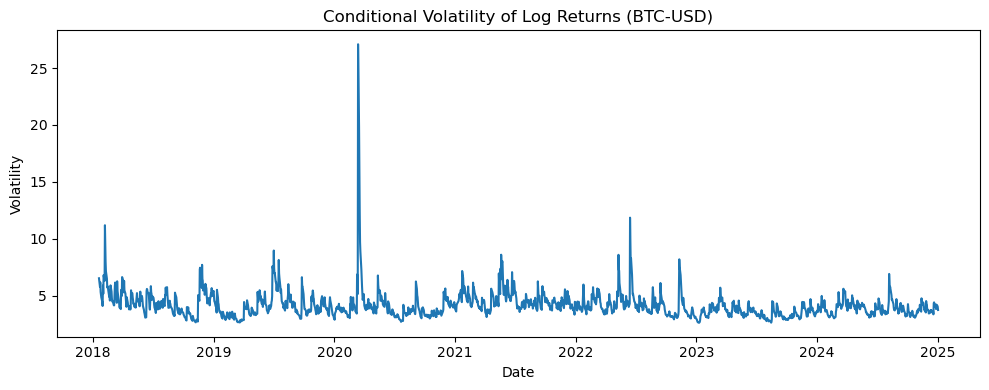

In [13]:
Volatility_BTC_USD = pd.DataFrame({
    'BTC_USD_Volatility': egarch_results['BTC_USD'].conditional_volatility
})
plt.figure(figsize=(10, 4))
plt.plot(Volatility_BTC_USD['BTC_USD_Volatility'])
plt.title("Conditional Volatility of Log Returns (BTC-USD)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

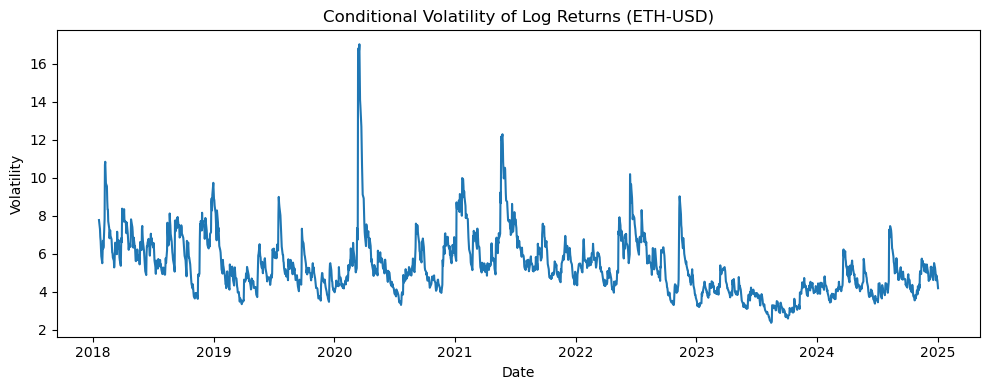

In [14]:
Volatility_ETH_USD = pd.DataFrame({
    'ETH_USD_Volatility': egarch_results['ETH_USD'].conditional_volatility
})
plt.figure(figsize=(10, 4))
plt.plot(Volatility_ETH_USD['ETH_USD_Volatility'])
plt.title("Conditional Volatility of Log Returns (ETH-USD)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

#### ADF Test for Conditional Volatility

In [15]:
cond_vols = pd.DataFrame({col: egarch_results[col].conditional_volatility 
                          for col in egarch_results.keys()})
adf_results = {}

for col in cond_vols.columns:
    result = adfuller(cond_vols[col])
    adf_results[col] = {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Used Lag': result[2],
        'Number of Observations': result[3],
        'Critical Values': result[4]
    }

for col, stats in adf_results.items():
    print(f"Conditional Volatility ADF Test for {col}:")
    print(f"  ADF Statistic: {stats['ADF Statistic']}")
    print(f"  p-value: {stats['p-value']}")
    print(f"  Critical Values: {stats['Critical Values']}")
    if stats['p-value'] < 0.05:
        print(f"  --> {name} is stationary.\n")
    else:
        print(f"  --> {name} is NOT stationary.\n")
    print("-------------------------------------------------")

Conditional Volatility ADF Test for BTC_USD:
  ADF Statistic: -11.915084933354814
  p-value: 5.187403177983047e-22
  Critical Values: {'1%': -3.4339740253219566, '5%': -2.863140805408186, '10%': -2.5676222161097058}
  --> USD_INR is stationary.

-------------------------------------------------
Conditional Volatility ADF Test for ETH_USD:
  ADF Statistic: -6.216972866758785
  p-value: 5.336508409971406e-08
  Critical Values: {'1%': -3.4339820768018106, '5%': -2.8631443597478143, '10%': -2.567624108684946}
  --> USD_INR is stationary.

-------------------------------------------------
Conditional Volatility ADF Test for EUR_USD:
  ADF Statistic: -3.819842416093197
  p-value: 0.0027107020912247913
  Critical Values: {'1%': -3.433968010099092, '5%': -2.8631381499714745, '10%': -2.567620802173316}
  --> USD_INR is stationary.

-------------------------------------------------
Conditional Volatility ADF Test for GBP_USD:
  ADF Statistic: -4.430031314735447
  p-value: 0.0002625395249706914
 

#### Descriptive Stats of Conditional Volatility

In [16]:
cond_vols.describe()

,BTC_USD,ETH_USD,EUR_USD,GBP_USD,AUD_USD,USD_CHF,USD_JPY,USD_INR
count,1811.000000,1811.000000,1811.000000,1811.000000,1811.000000,1811.000000,1811.000000,1811.000000
mean,4.154693,5.367193,0.433040,0.530374,0.616651,0.442871,0.512618,0.297754
std,1.215930,1.575260,0.094913,0.135434,0.141457,0.077827,0.172303,0.117342
min,2.607822,2.377151,0.263164,0.322535,0.374160,0.276884,0.251373,0.079666
25%,3.478800,4.280558,0.364446,0.446813,0.533580,0.388503,0.382793,0.217663
50%,3.937201,5.137291,0.424599,0.499271,0.588714,0.431463,0.454827,0.295967
75%,4.516338,6.188929,0.481002,0.572424,0.661626,0.480738,0.606310,0.374259
max,27.090080,17.010932,0.849492,1.272250,1.283877,0.908837,1.380613,0.661246


#### Fitting VAR(2) Model to Log Returns

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 23, Jan, 2026
Time:                     15:51:23
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -79.6358
Nobs:                     1809.00    HQIC:                  -79.8967
Log likelihood:           52005.7    FPE:                1.71799e-35
AIC:                     -80.0493    Det(Omega_mle):     1.59413e-35
--------------------------------------------------------------------
Results for equation BTC_USD
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.001086         0.000998            1.088           0.276
L1.BTC_USD        -0.002258         0.041533           -0.054           0.957
L1.ETH_USD        -0.021622         0.031780           -0.680         

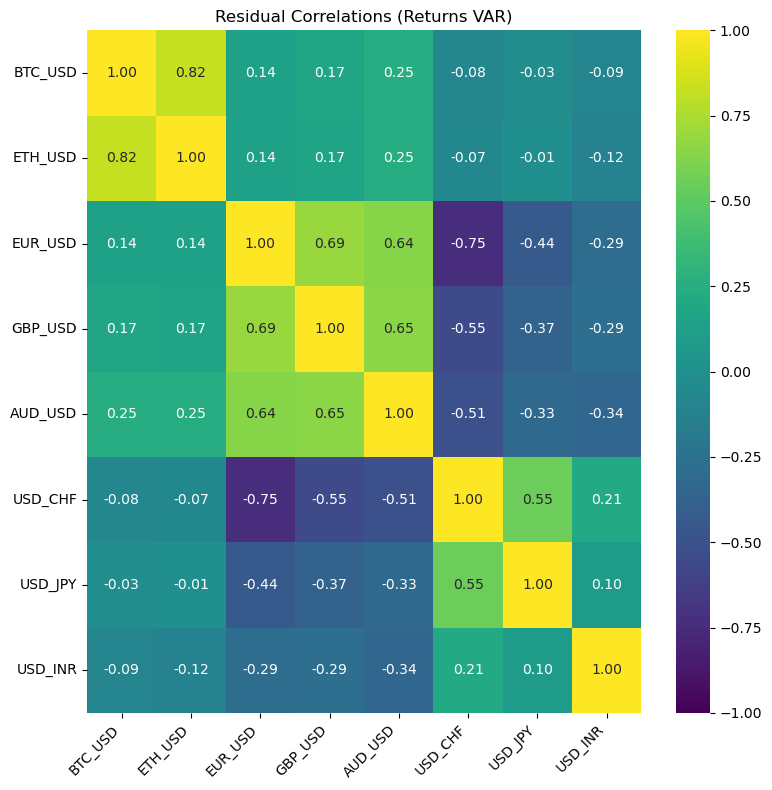

In [17]:
model = VAR(log_returns)
var_res = model.fit(2)
print(var_res.summary())
correlation_matrix = var_res.resid.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1)
plt.title('Residual Correlations (Returns VAR)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Generalized FEVD Spillovers for Log Returns

In [18]:
def generalized_fevd(var_res, H=10):
    sigma_u = var_res.sigma_u.values
    n = sigma_u.shape[0]
    theta = var_res.ma_rep(H)
    fevd = np.zeros((n, n))

    for j in range(n):
        for i in range(n):
            num, den = 0.0, 0.0
            for h in range(H):
                num += (theta[h, j, i] ** 2) * sigma_u[i, i]
                den += theta[h, j, :] @ sigma_u @ theta[h, j, :].T
            fevd[j, i] = num / den

    return fevd / fevd.sum(axis=1, keepdims=True)
H = 10
fevd_matrix = generalized_fevd(var_res, H=H)

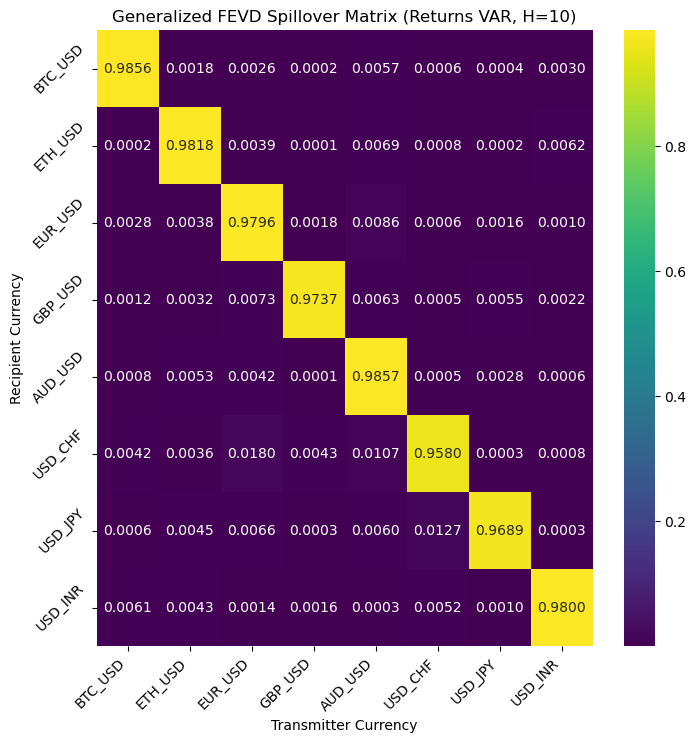

In [19]:
currency_names = (
    log_returns.columns
)

fevd_df = pd.DataFrame(
    fevd_matrix,
    index=currency_names,
    columns=currency_names
)

plt.figure(figsize=(8, 8))
sns.heatmap(fevd_df, annot=True, cmap="viridis", fmt=".4f")
plt.title("Generalized FEVD Spillover Matrix (Returns VAR, H=10)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=45)
plt.xlabel("Transmitter Currency")
plt.ylabel("Recipient Currency")
plt.show()

#### Fitting VAR(5) Model to Conditional Volatility

In [20]:
var_data = cond_vols.copy()
var_model = VAR(var_data)
lag_order_results = var_model.select_order(maxlags=10)
print("Optimal lag order by AIC:", lag_order_results.aic)
optimal_lag = lag_order_results.aic
var_result = var_model.fit(optimal_lag)
print(var_result.summary())

fevd = var_result.fevd(10)
fevd.summary()

Optimal lag order by AIC: 5
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 23, Jan, 2026
Time:                     15:51:24
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -48.9062
Nobs:                     1806.00    HQIC:                  -49.5363
Log likelihood:           24891.3    FPE:                2.12131e-22
AIC:                     -49.9049    Det(Omega_mle):     1.77260e-22
--------------------------------------------------------------------
Results for equation BTC_USD
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.719948         0.125134            5.753           0.000
L1.BTC_USD         0.635000         0.042296           15.013           0.000
L1.ETH_USD         0.152734         0.0644

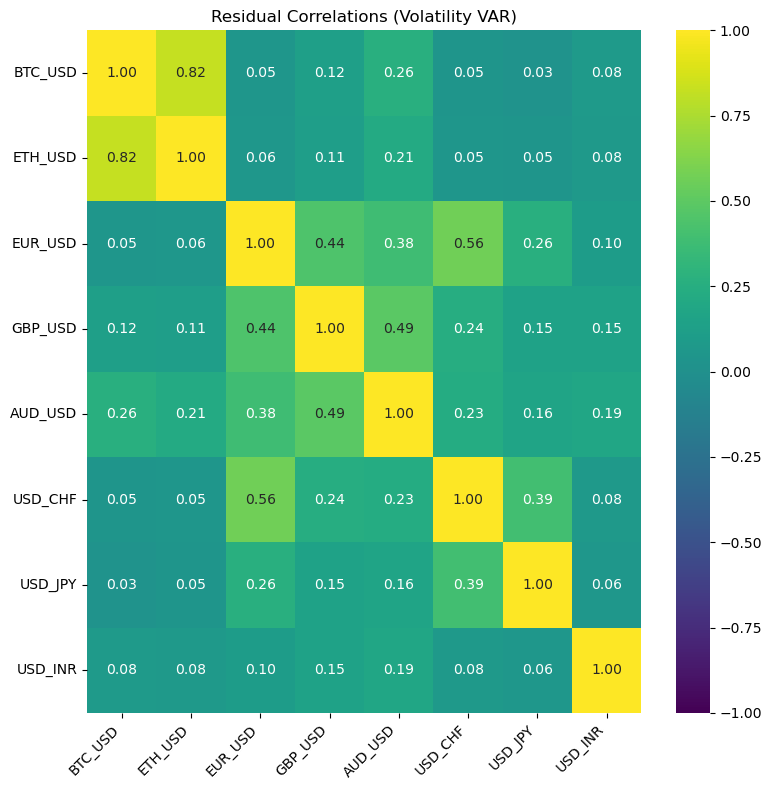

In [21]:
correlation_matrix = var_result.resid.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1)
plt.title('Residual Correlations (Volatility VAR)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Generalized FEVD Spillovers for Conditional Volatility

In [22]:
def generalized_fevd(var_res, H=10):
    sigma_u = var_res.sigma_u.values
    theta = var_res.ma_rep(H)
    n = sigma_u.shape[0]

    fevd = np.zeros((n, n))

    for j in range(n):              
        for i in range(n):          
            num = 0.0
            den = 0.0
            for h in range(H):
                num += (theta[h, j, i] ** 2) * sigma_u[i, i]
                den += theta[h, j, :] @ sigma_u @ theta[h, j, :].T
            fevd[j, i] = num / den

    return fevd / fevd.sum(axis=1, keepdims=True)

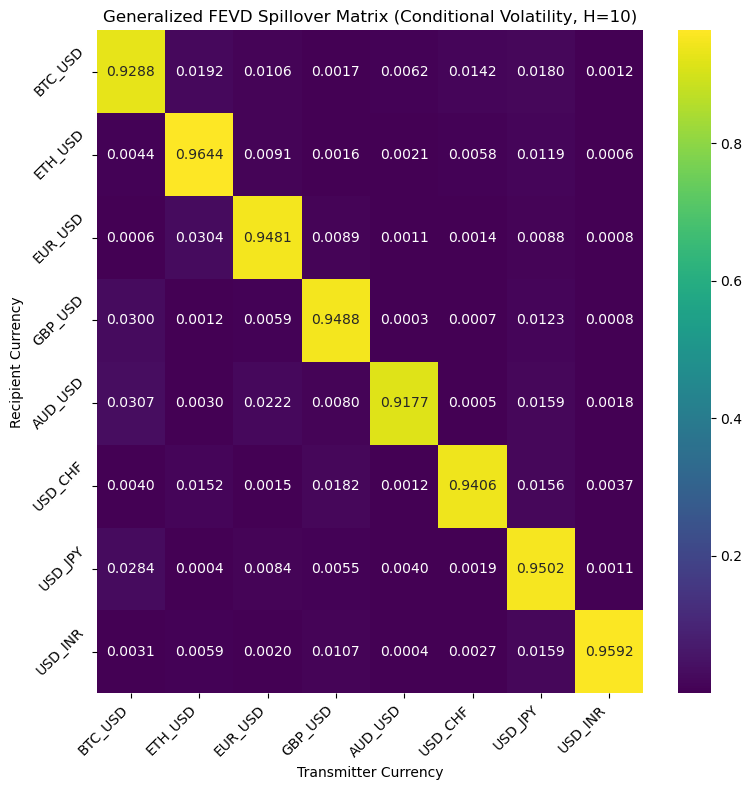

In [23]:
H = 10
fevd_matrix = generalized_fevd(var_result, H=H)

fevd_df = pd.DataFrame(
    fevd_matrix,
    index=cond_vols.columns,
    columns=[f"{c}" for c in cond_vols.columns]
)

plt.figure(figsize=(8, 8))
sns.heatmap(fevd_df, annot=True, fmt=".4f", cmap="viridis")
plt.title("Generalized FEVD Spillover Matrix (Conditional Volatility, H=10)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=45)
plt.xlabel("Transmitter Currency")
plt.ylabel("Recipient Currency")
plt.tight_layout()
plt.show()

#### Plotting Rolling Total Spillover Indices

In [ ]:
def rolling_fevd(data, window=300, H=10, lags=2):
    fevd_time_series = {var: [] for var in data.columns}
    total_spillover_list = []
    index_list = []
    for start in range(0, len(data) - window + 1):
        end = start + window
        window_data = data.iloc[start:end]
        try:
            model = VAR(window_data)
            var_res = model.fit(lags)
            fevd_matrix = generalized_fevd(var_res, H=H)
            total_spillover = (np.sum(fevd_matrix) - np.trace(fevd_matrix)) / np.sum(fevd_matrix) * 100
            total_spillover_list.append(total_spillover)
            for j, var in enumerate(data.columns):
                fevd_time_series[var].append(fevd_matrix[j, :])
            index_list.append(window_data.index[-1])
        except Exception as e:
            print(f"Error at window ending {window_data.index[-1]}: {e}")
            continue
    fevd_dfs = {}
    for var in data.columns:
        fevd_dfs[var] = pd.DataFrame(
            fevd_time_series[var],
            index=index_list,
            columns=data.columns
        )
    total_spillover_series = pd.Series(
        total_spillover_list,
        index=index_list,
        name='Total_Spillover'
    )
    return fevd_dfs, total_spillover_series

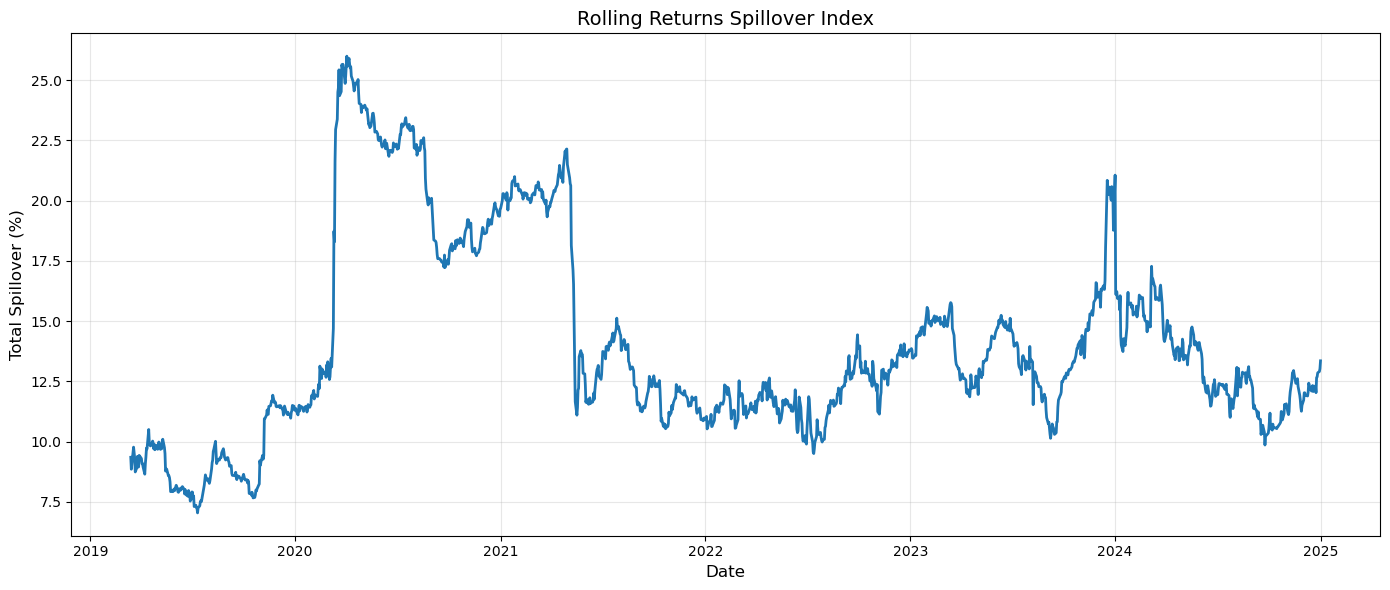

In [28]:
fevd_dfs_returns, total_spillover_returns = rolling_fevd(
    log_returns, 
    window=300, 
    H=10, 
    lags=2
)
plt.figure(figsize=(14, 6))
plt.plot(total_spillover_returns.index, total_spillover_returns.values, linewidth=2)
plt.title('Rolling Returns Spillover Index', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Spillover (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

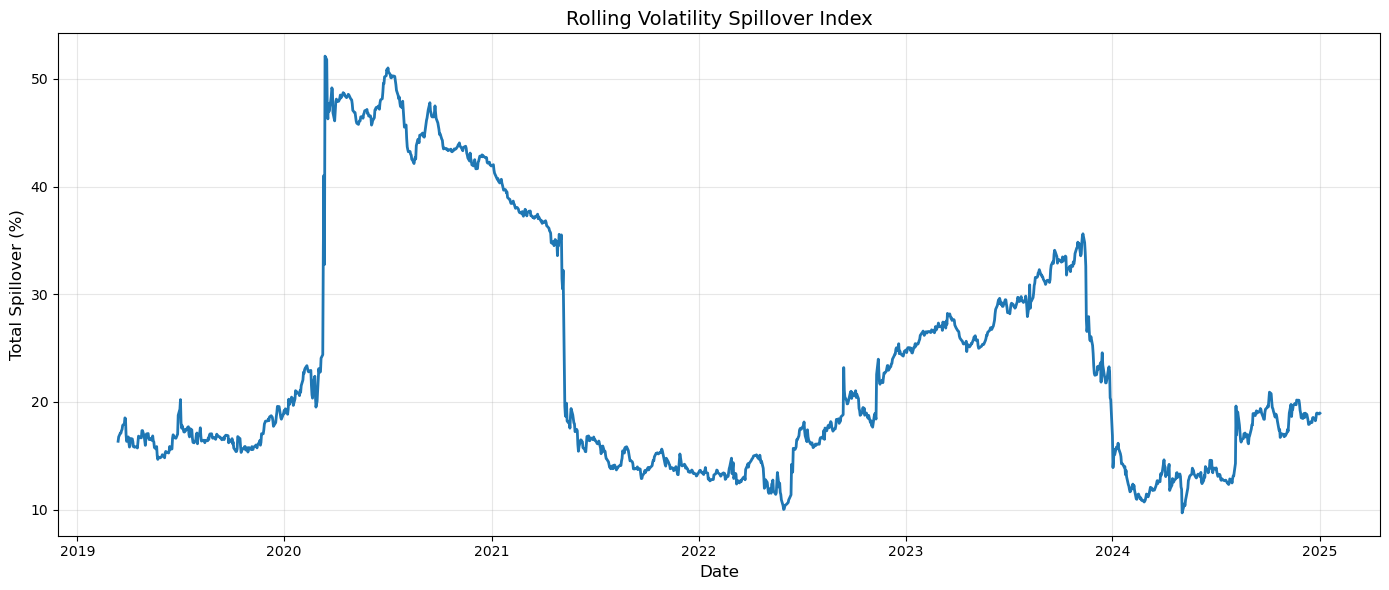

In [29]:
fevd_dfs_returns, total_spillover_returns = rolling_fevd(
    cond_vols, 
    window=300, 
    H=10, 
    lags=2
)
plt.figure(figsize=(14, 6))
plt.plot(total_spillover_returns.index, total_spillover_returns.values, linewidth=2)
plt.title('Rolling Volatility Spillover Index', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Spillover (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()